In [1]:
from PIL import Image

In [2]:
image=Image.open("/content/img1.jpg")

In [3]:
image_resized=image.resize((400,224))

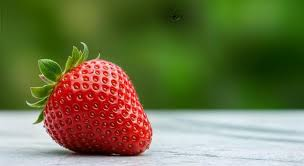

In [4]:
image

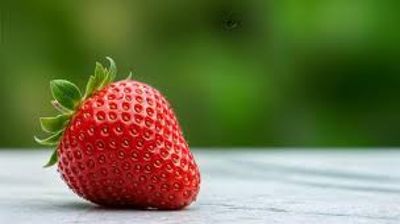

In [5]:
image_resized


In [7]:
import numpy as np
image_array=np.array(image)/255.0  #normalise to 0 to 1
image_array

array([[[0.19607843, 0.31372549, 0.03921569],
        [0.19607843, 0.31372549, 0.03921569],
        [0.19607843, 0.31372549, 0.03921569],
        ...,
        [0.16470588, 0.38823529, 0.01960784],
        [0.16078431, 0.38431373, 0.01568627],
        [0.16078431, 0.38431373, 0.01568627]],

       [[0.19607843, 0.31372549, 0.03921569],
        [0.19607843, 0.31372549, 0.03921569],
        [0.19607843, 0.31372549, 0.03921569],
        ...,
        [0.16470588, 0.38823529, 0.01960784],
        [0.16078431, 0.38431373, 0.01568627],
        [0.16078431, 0.38431373, 0.01568627]],

       [[0.19607843, 0.31372549, 0.03921569],
        [0.19607843, 0.31372549, 0.03921569],
        [0.19607843, 0.31372549, 0.03921569],
        ...,
        [0.16862745, 0.39215686, 0.02352941],
        [0.16470588, 0.38823529, 0.01960784],
        [0.16078431, 0.38431373, 0.01568627]],

       ...,

       [[0.83137255, 0.85882353, 0.89803922],
        [0.83137255, 0.85882353, 0.89803922],
        [0.82745098, 0

array([[ 56,  56,  56, ...,  64,  63,  63],
       [ 56,  56,  56, ...,  64,  63,  63],
       [ 56,  56,  56, ...,  65,  64,  63],
       ...,
       [221, 221, 220, ..., 213, 214, 217],
       [221, 221, 220, ..., 223, 225, 228],
       [221, 221, 220, ..., 221, 223, 225]], dtype=uint8)
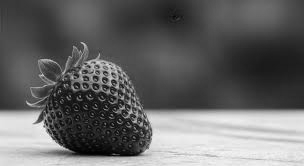

In [8]:
from cv2 import cvtColor, COLOR_BGR2GRAY
image_np=np.array(image)
grayscale_image=cvtColor(image_np, COLOR_BGR2GRAY)
grayscale_image

Image Preprocessing and Data Augmentation

In [11]:
from PIL import Image, ImageEnhance, ImageOps
#PIL python imaging lib via pillow for image preprocessing


In [13]:
import os

In [14]:
flipped=ImageOps.mirror(image)

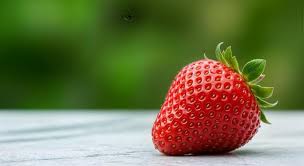

In [15]:
flipped

In [16]:
rotated=image.rotate(30)

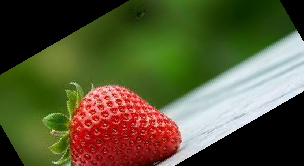

In [17]:
rotated

In [18]:
enhancer=ImageEnhance.Brightness(image)

In [19]:
brighter=enhancer.enhance(1.5)

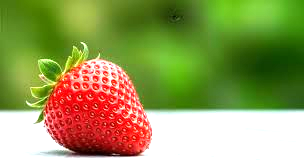

In [21]:
brighter

In [24]:
contrast=ImageEnhance.Contrast(image).enhance(3.0)

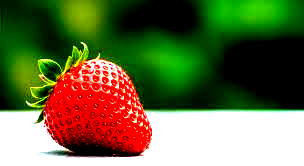

In [25]:
contrast

In [27]:
grayscale=ImageOps.grayscale(image)

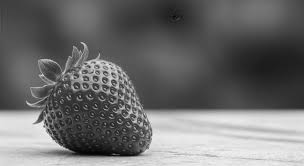

In [28]:
grayscale

In [29]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = "/content/img1.jpg"  # Replace with your image file path
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


In [30]:
from PIL import Image
import matplotlib.pyplot as plt
import os

In [32]:
augmented_dir = "augmented_images"
#directory where augmented images are stored

In [39]:
augmented_images = os.listdir(augmented_dir)
#list all augmented image files
#list all files in the augmented_images directory and store

In [34]:
plt.figure(figsize=(12,8))
#plot each augmented image and adjust the size of the plot

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

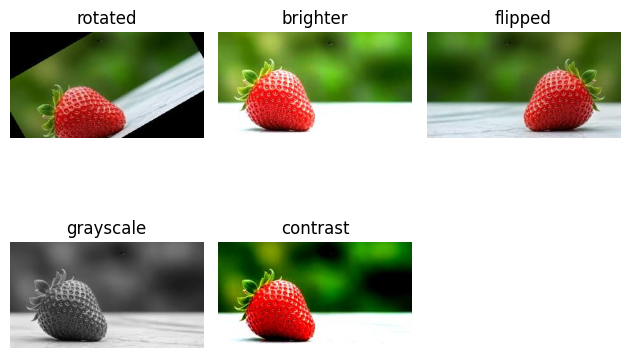

In [38]:
for i, img_file in enumerate(augmented_images):
  #open each image
  img_path = os.path.join(augmented_dir,img_file)
  #combines directory path and image file
  img=Image.open(img_path)
  plt.subplot(2,3,i+1)
  #display img
  plt.imshow(img,cmap="gray" if img.mode=="L" else None)
  plt.title(img_file.split('.')[0])
  plt.axis('off')
plt.tight_layout()
plt.show()